# WR503 上手／下手震動比較：2026-03-26 vs 2026-08-27

比較相同條件的原始／濾波前量測，上手只和上手比、下手只和下手比。所有時間序列圖使用完全相同的 y 軸範圍與刻度，紅色虛線為 ±0.3 g 門檻。

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.unicode_minus"] = False


In [2]:
DATASETS = {
    "2026-03-26 upper/raw": Path(r"C:\ITRI\歐陽\SAA\WR503\震動量測\20260326\上手\RecData--20260326133043上手.csv"),
    "2026-08-27 upper J5/raw": Path(r"C:\ITRI\歐陽\SAA\WR503\震動量測\20260827_vib test\濾波前\上手J5\RecData--20260827115016.csv"),
    "2026-03-26 lower/raw": Path(r"C:\ITRI\歐陽\SAA\WR503\震動量測\20260326\下手\RecData--20260326133043下手.csv"),
    "2026-08-27 lower J4/raw": Path(r"C:\ITRI\歐陽\SAA\WR503\震動量測\20260827_vib test\濾波前\下手J4\RecData--20260827115019.csv"),
}
GROUPS = {
    "Upper gripper": [label for label in DATASETS if "upper" in label],
    "Lower gripper": [label for label in DATASETS if "lower" in label],
}
THRESHOLD_G = 0.3
Y_PADDING_RATIO = 0.03  # Add 3% beyond the largest absolute value
Y_TICK_STEP_G = 0.2     # Common, readable tick spacing
DISPLAY_MAX_POINTS = 60_000

missing = [str(path) for path in DATASETS.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing CSV:\n" + "\n".join(missing))


In [3]:
def load_recdata(path):
    with path.open("r", encoding="utf-8-sig", errors="replace") as stream:
        preview = [stream.readline() for _ in range(30)]
    header_row = next(
        i for i, line in enumerate(preview)
        if "time" in line.lower() and "," in line
    )
    metadata = {}
    for line in preview[:header_row]:
        if ":" in line:
            key, value = line.split(":", 1)
            metadata[key.strip()] = value.strip()
    frame = pd.read_csv(path, skiprows=header_row)
    frame.columns = frame.columns.str.strip()
    frame = frame.rename(columns={"Time": "time_s", "X-axis": "X", "Y-axis": "Y", "Z-axis": "Z"})
    required = ["time_s", "X", "Y", "Z"]
    if not set(required).issubset(frame.columns):
        raise ValueError(f"Unexpected columns in {path}: {list(frame.columns)}")
    frame = frame[required].apply(pd.to_numeric, errors="coerce").dropna()
    frame = frame.sort_values("time_s").drop_duplicates("time_s")
    return frame, metadata

series = {}
metadata = {}
for label, path in DATASETS.items():
    series[label], metadata[label] = load_recdata(path)
    print(f"{label}: {len(series[label]):,} samples, {series[label].time_s.iloc[-1]:.3f} s, metadata={metadata[label]}")

# Derive one compact symmetric y scale from the largest absolute value in all six datasets.
global_abs_max = max(frame[["X", "Y", "Z"]].abs().to_numpy().max() for frame in series.values())
Y_LIMIT_G = np.ceil(global_abs_max * (1 + Y_PADDING_RATIO) / 0.1) * 0.1
Y_TICKS_G = np.arange(-Y_LIMIT_G, Y_LIMIT_G + Y_TICK_STEP_G / 2, Y_TICK_STEP_G)
print(f"Common y range: {-Y_LIMIT_G:.1f} to {Y_LIMIT_G:.1f} g; ticks every {Y_TICK_STEP_G:.1f} g (global max |g|={global_abs_max:.6f})")


2026-03-26 upper/raw: 402,432 samples, 392.999 s, metadata={'Date/Time': '2026/03/26 13:30:43', 'SamplingRate': '1024.0', 'SensorMAC': '', 'Unit': 'g'}
2026-08-27 upper J5/raw: 359,936 samples, 351.499 s, metadata={'Date/Time': '2026/08/27 11:50:16', 'SamplingRate': '1024.0', 'SensorMAC': '', 'Unit': 'g'}


2026-03-26 lower/raw: 201,216 samples, 392.998 s, metadata={'Date/Time': '2026/03/26 13:30:43', 'SamplingRate': '512.0', 'SensorMAC': 'D8:07:2E:2C:05:20', 'Unit': 'g'}
2026-08-27 lower J4/raw: 363,520 samples, 354.999 s, metadata={'Date/Time': '2026/08/27 11:50:19', 'SamplingRate': '1024.0', 'SensorMAC': '', 'Unit': 'g'}
Common y range: -1.7 to 1.7 g; ticks every 0.2 g (global max |g|=1.598856)


In [4]:
rows = []
for label, frame in series.items():
    dt = frame.time_s.diff().dropna().median()
    for axis in ["X", "Y", "Z"]:
        values = frame[axis].to_numpy()
        absolute = np.abs(values)
        exceeded = absolute >= THRESHOLD_G  # Vendor requirement is strictly < 0.3 g
        transitions = np.diff(np.r_[False, exceeded, False].astype(np.int8))
        run_lengths = np.flatnonzero(transitions == -1) - np.flatnonzero(transitions == 1)
        event_count = len(run_lengths)
        rows.append({
            "dataset": label,
            "axis": axis,
            "samples": len(values),
            "sampling_rate_Hz": 1 / dt,
            "mean_g": values.mean(),
            "std_g": values.std(ddof=1),
            "RMS_g": np.sqrt(np.mean(values ** 2)),
            "p95_abs_g": np.percentile(absolute, 95),
            "p99_abs_g": np.percentile(absolute, 99),
            "p99.9_abs_g": np.percentile(absolute, 99.9),
            "max_abs_g": absolute.max(),
            "min_g": values.min(),
            "max_g": values.max(),
            "within_0.3g_pct": 100 * np.mean(absolute < THRESHOLD_G),
            "outside_0.3g_count": np.count_nonzero(exceeded),
            "outside_0.3g_pct": 100 * np.mean(exceeded),
            "outside_0.3g_seconds": np.count_nonzero(exceeded) * dt,
            "exceedance_events": event_count,
            "exceedance_events_per_min": event_count / (len(values) * dt / 60),
            "max_exceedance_duration_ms": (run_lengths.max() * dt * 1000) if event_count else 0.0,
        })
metrics = pd.DataFrame(rows).set_index(["dataset", "axis"])
display(metrics.round(6))


samples  sampling_rate_Hz    mean_g     std_g  \
dataset                 axis                                                  
2026-03-26 upper/raw    X      402432       1024.000524  0.000019  0.088205   
                        Y      402432       1024.000524 -0.000002  0.089883   
                        Z      402432       1024.000524 -0.000003  0.047139   
2026-08-27 upper J5/raw X      359936       1024.000524 -0.000006  0.100065   
                        Y      359936       1024.000524 -0.000007  0.106029   
                        Z      359936       1024.000524  0.000001  0.054572   
2026-03-26 lower/raw    X      201216        512.000000  0.000018  0.093470   
                        Y      201216        512.000000 -0.000009  0.092241   
                        Z      201216        512.000000 -0.000012  0.048630   
2026-08-27 lower J4/raw X      363520       1024.000524 -0.000020  0.108224   
                        Y      363520       1024.000524  0.000005  0.136000   
                        Z      363520       1024.000524 -0.000000  0.058328   

                                 RMS_g  p95_abs_g  p99_abs_g  p99.9_abs_g  \
dataset                 axis                                                
2026-03-26 upper/raw    X     0.088205   0.186365   0.371715     0.616881   
                        Y     0.089883   0.171886   0.368652     0.741996   
                        Z     0.047139   0.088707   0.202393     0.370173   
2026-08-27 upper J5/raw X     0.100065   0.218929   0.395043     0.638530   
                        Y     0.106029   0.218162   0.404311     0.832385   
                        Z     0.054572   0.099186   0.222711     0.465076   
2026-03-26 lower/raw    X     0.093470   0.190617   0.361968     0.755533   
                        Y     0.092241   0.187261   0.397998     0.725924   
                        Z     0.048629   0.085614   0.200044     0.437756   
2026-08-27 lower J4/raw X     0.108224   0.225666   0.413793     0.795757   
                        Y     0.135999   0.282231   0.568434     0.960845   
                        Z     0.058328   0.089419   0.214505     0.689653   

                              max_abs_g     min_g     max_g  within_0.3g_pct  \
dataset                 axis                                                   
2026-03-26 upper/raw    X      0.812133 -0.757856  0.812133        98.265049   
                        Y      1.136167 -1.051761  1.136167        98.429548   
                        Z      1.194493 -1.052761  1.194493        99.720947   
2026-08-27 upper J5/raw X      0.811142 -0.804620  0.811142        97.625967   
                        Y      0.964001 -0.964001  0.949299        97.736264   
                        Z      1.127728 -1.092902  1.127728        99.595206   
2026-03-26 lower/raw    X      0.906812 -0.848936  0.906812        98.427063   
                        Y      0.940693 -0.940693  0.915696        98.002147   
                        Z      0.788484 -0.649600  0.788484        99.616333   
2026-08-27 lower J4/raw X      0.995267 -0.995267  0.883119        97.541538   
                        Y      1.598856 -1.598856  1.128894        95.510288   
                        Z      1.071680 -1.071680  1.050425        99.462753   

                              outside_0.3g_count  outside_0.3g_pct  \
dataset                 axis                                         
2026-03-26 upper/raw    X                   6982          1.734951   
                        Y                   6320          1.570452   
                        Z                   1123          0.279053   
2026-08-27 upper J5/raw X                   8545          2.374033   
                        Y                   8148          2.263736   
                        Z                   1457          0.404794   
2026-03-26 lower/raw    X                   3165          1.572937   
                        Y                   4020          1.997853   
                       

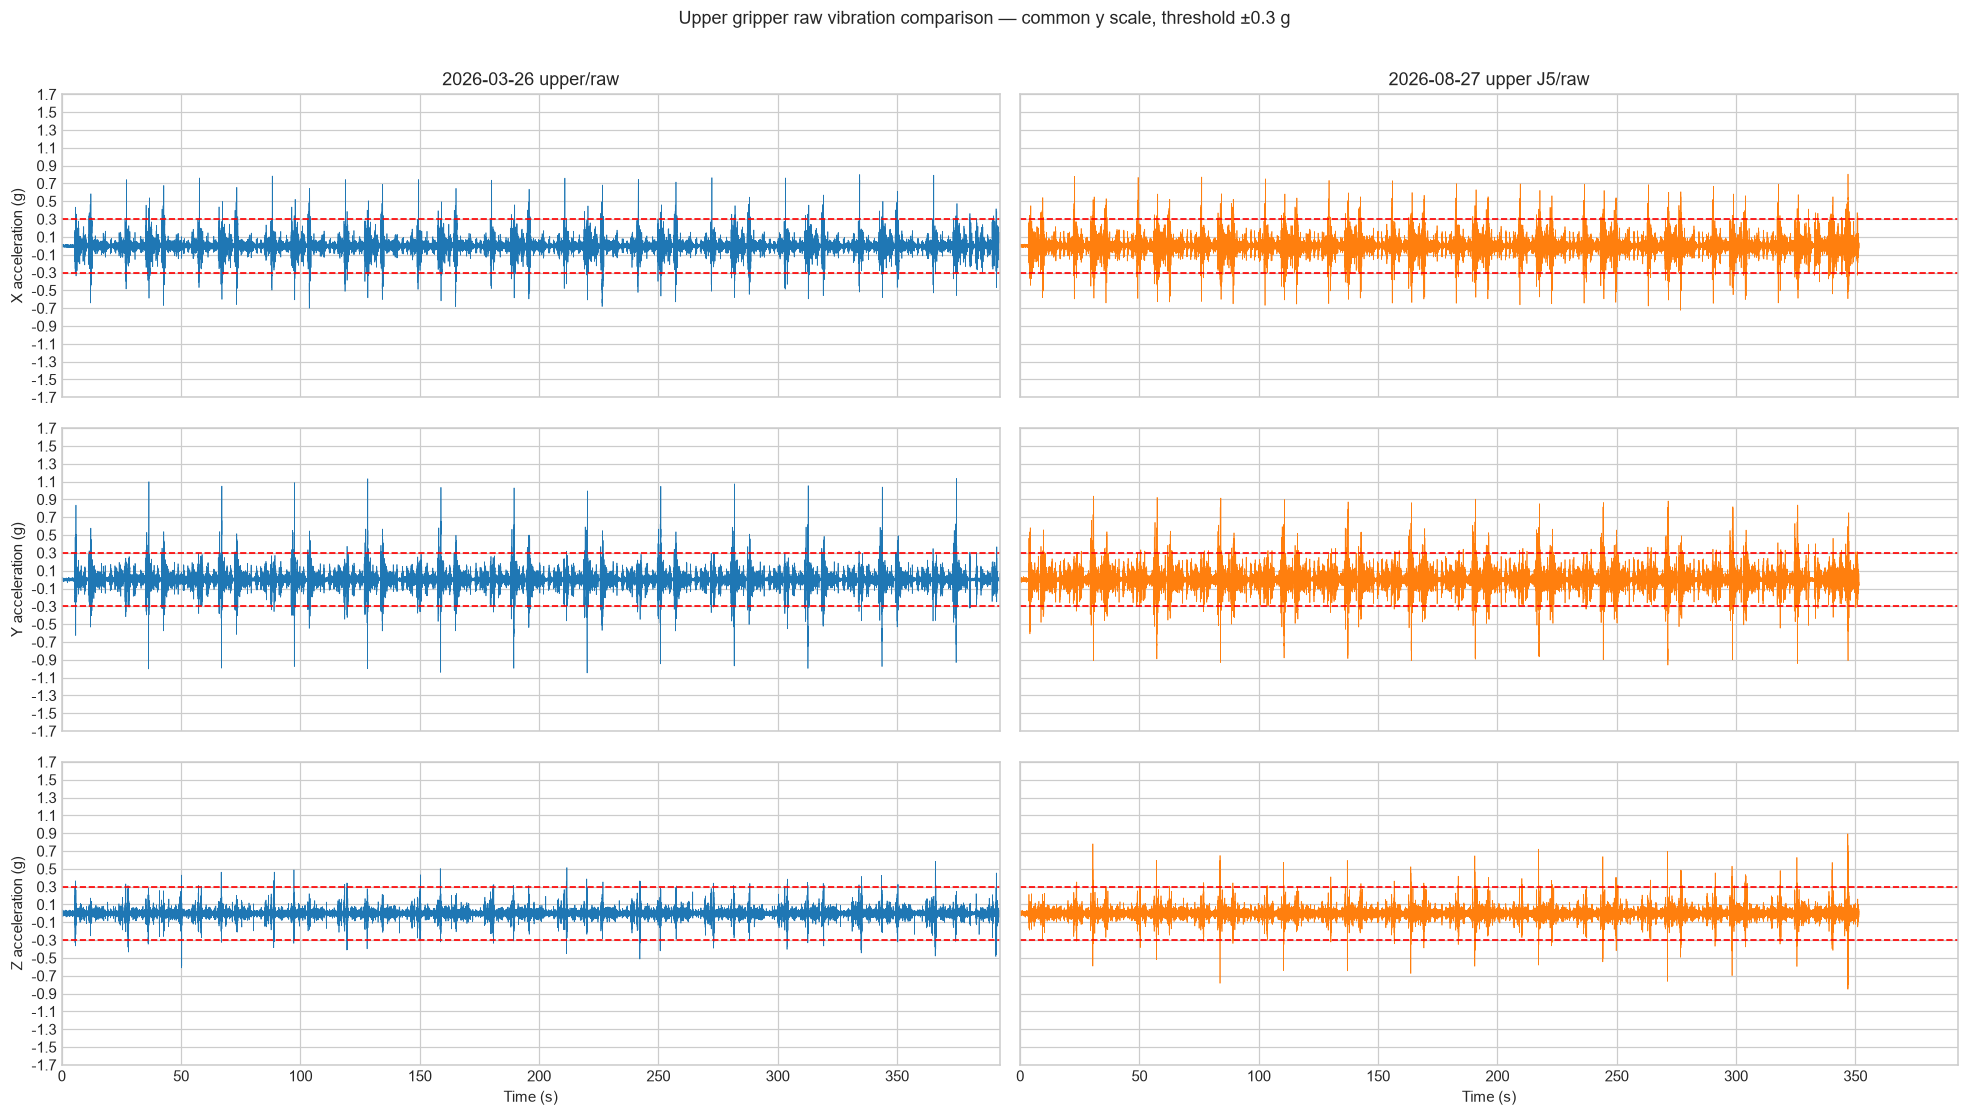

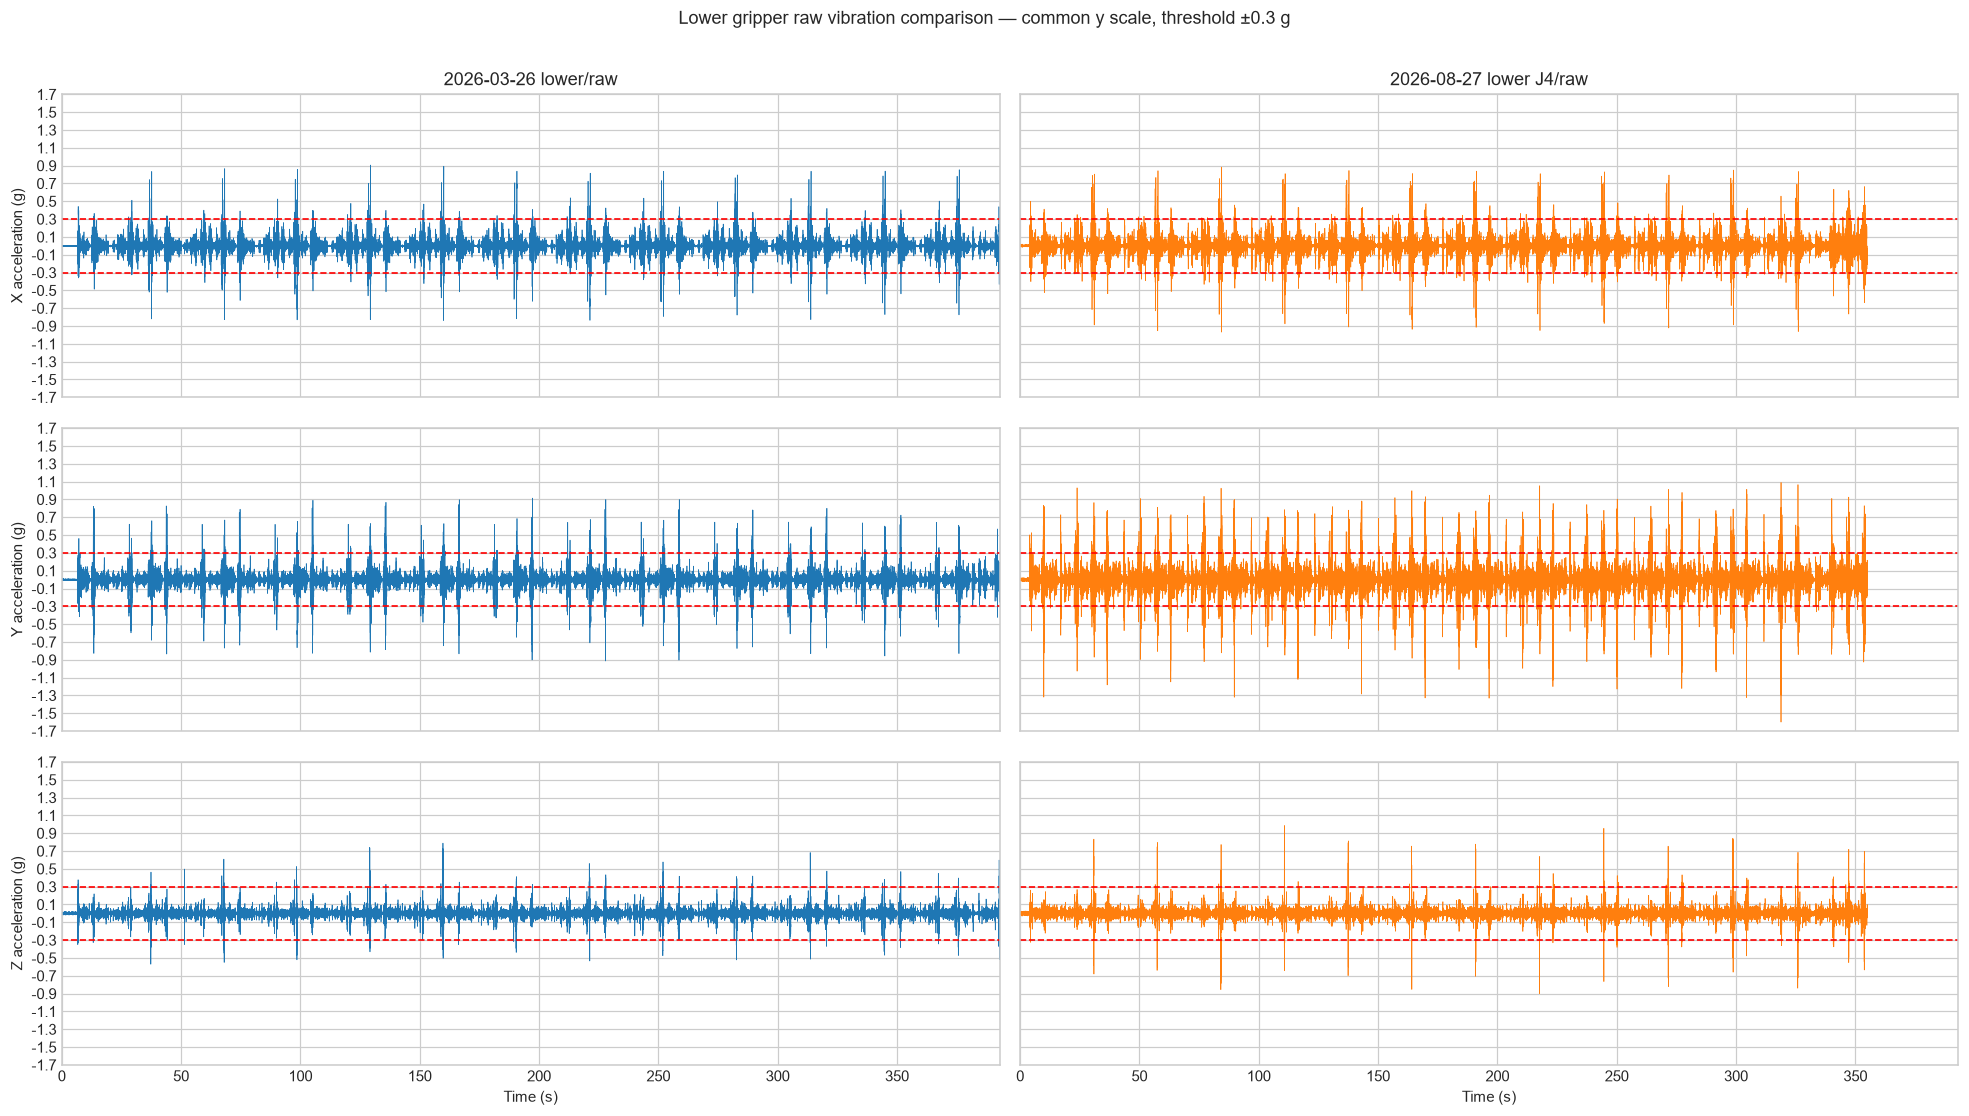

In [5]:
# Rows are axes and columns are dates/runs; upper and lower grippers are separate figures.
axes_names = ["X", "Y", "Z"]
global_duration = max(frame.time_s.iloc[-1] for frame in series.values())
for gripper, labels in GROUPS.items():
    fig, axs = plt.subplots(3, len(labels), figsize=(18, 10), sharex=True, sharey=True, squeeze=False)
    for col, label in enumerate(labels):
        frame = series[label]
        step = max(1, int(np.ceil(len(frame) / DISPLAY_MAX_POINTS)))
        view = frame.iloc[::step]
        for row, axis in enumerate(axes_names):
            ax = axs[row, col]
            ax.plot(view.time_s, view[axis], linewidth=0.45, color=f"C{col}")
            ax.axhline(THRESHOLD_G, color="red", linestyle="--", linewidth=1.1)
            ax.axhline(-THRESHOLD_G, color="red", linestyle="--", linewidth=1.1)
            ax.set_ylim(-Y_LIMIT_G, Y_LIMIT_G)
            ax.set_yticks(Y_TICKS_G)
            ax.set_xlim(0, global_duration)
            if row == 0:
                ax.set_title(label)
            if col == 0:
                ax.set_ylabel(f"{axis} acceleration (g)")
            if row == 2:
                ax.set_xlabel("Time (s)")
    fig.suptitle(f"{gripper} raw vibration comparison — common y scale, threshold ±0.3 g", y=1.01)
    fig.tight_layout()
    plt.show()


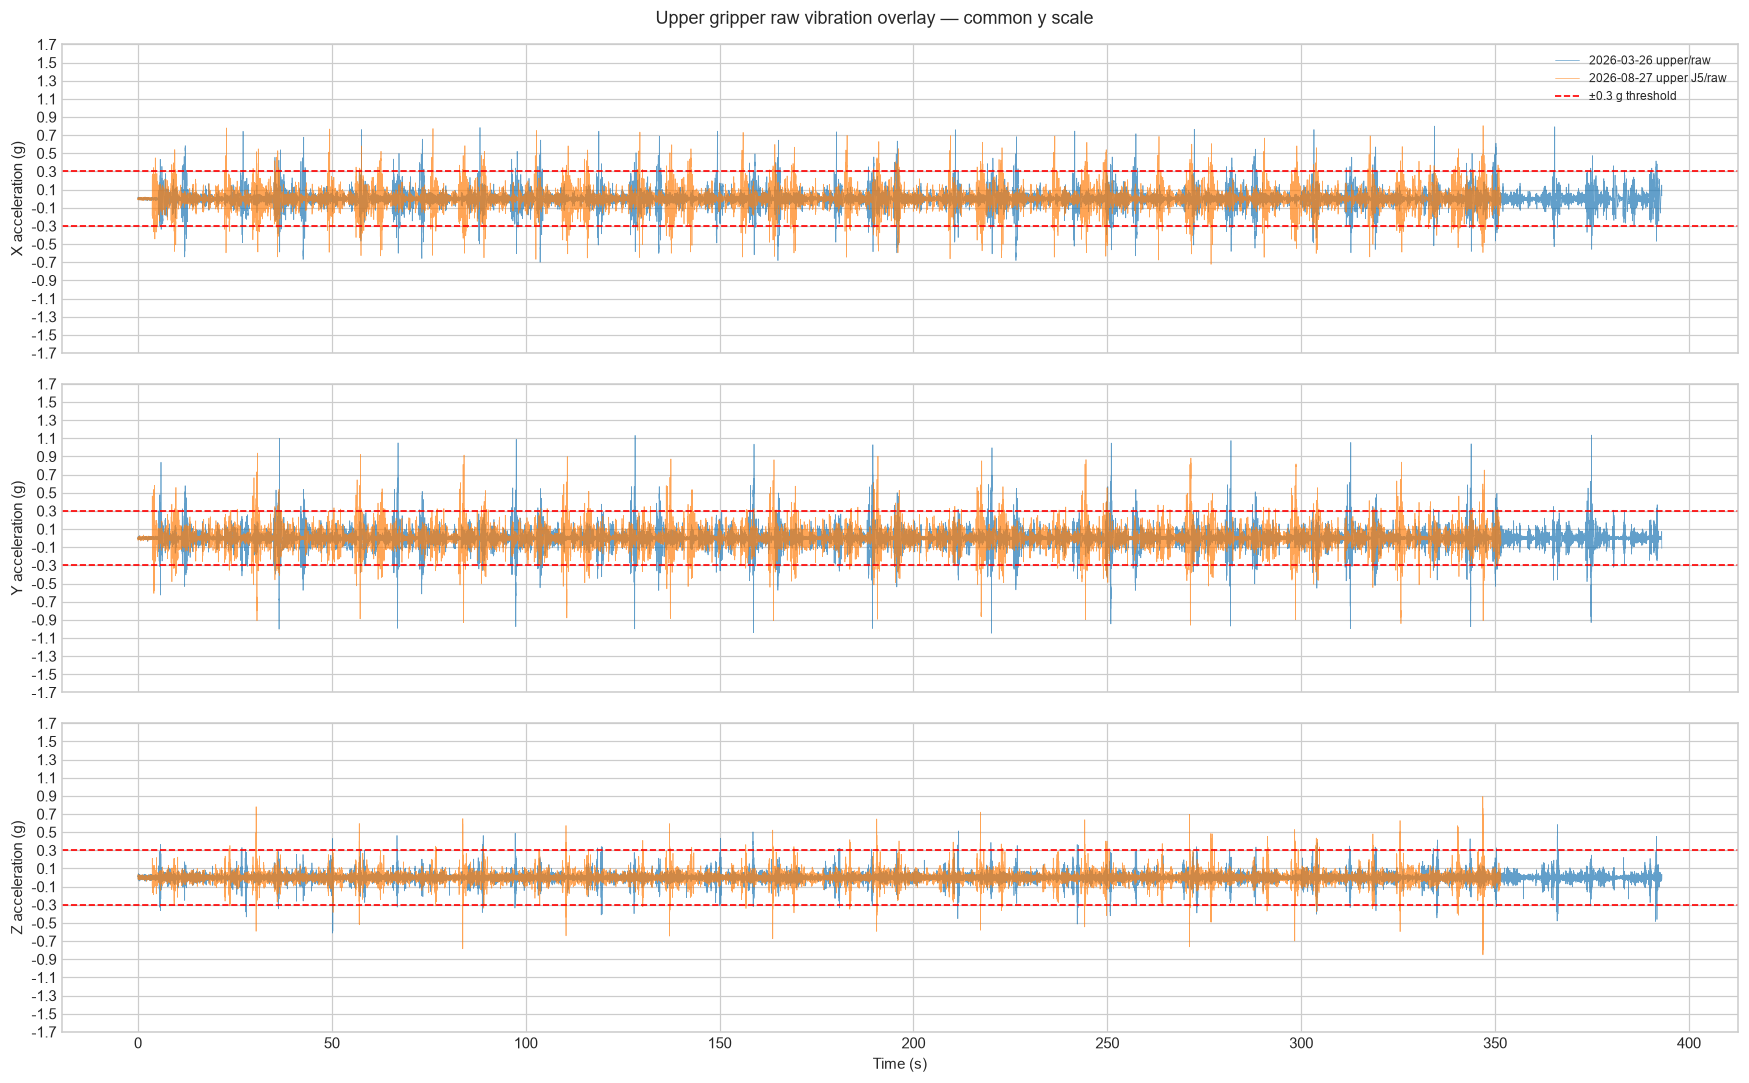

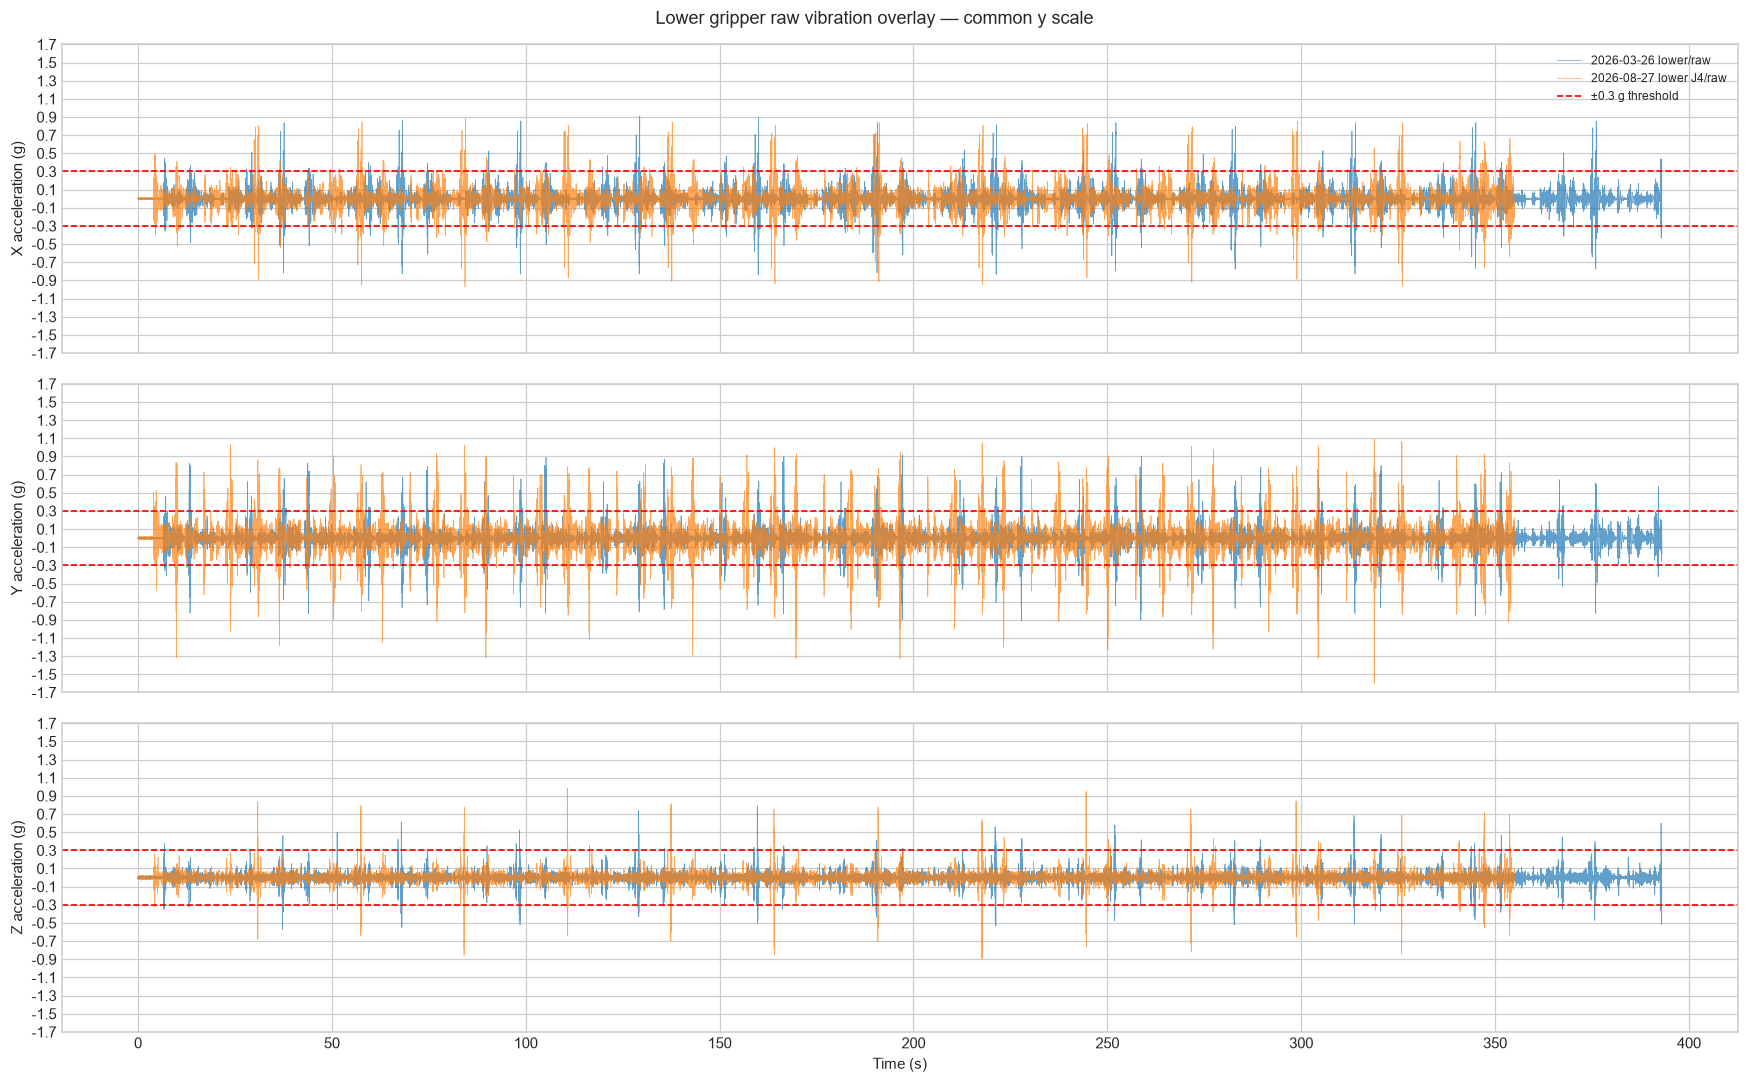

In [6]:
# Overlay view makes amplitude and timing differences easier to compare directly.
for gripper, labels in GROUPS.items():
    fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True, sharey=True)
    for axis, ax in zip(axes_names, axs):
        for label in labels:
            frame = series[label]
            step = max(1, int(np.ceil(len(frame) / DISPLAY_MAX_POINTS)))
            view = frame.iloc[::step]
            ax.plot(view.time_s, view[axis], linewidth=0.45, alpha=0.7, label=label)
        ax.axhline(THRESHOLD_G, color="red", linestyle="--", linewidth=1.1, label="±0.3 g threshold" if axis == "X" else None)
        ax.axhline(-THRESHOLD_G, color="red", linestyle="--", linewidth=1.1)
        ax.set_ylim(-Y_LIMIT_G, Y_LIMIT_G)
        ax.set_yticks(Y_TICKS_G)
        ax.set_ylabel(f"{axis} acceleration (g)")
    axs[0].legend(loc="upper right", fontsize=8)
    axs[-1].set_xlabel("Time (s)")
    fig.suptitle(f"{gripper} raw vibration overlay — common y scale")
    fig.tight_layout()
    plt.show()


RMS_g     min_g     max_g  \
dataset                 axis                                 
2026-03-26 upper/raw    X     0.088205 -0.757856  0.812133   
                        Y     0.089883 -1.051761  1.136167   
                        Z     0.047139 -1.052761  1.194493   
2026-08-27 upper J5/raw X     0.100065 -0.804620  0.811142   
                        Y     0.106029 -0.964001  0.949299   
                        Z     0.054572 -1.092902  1.127728   
2026-03-26 lower/raw    X     0.093470 -0.848936  0.906812   
                        Y     0.092241 -0.940693  0.915696   
                        Z     0.048629 -0.649600  0.788484   
2026-08-27 lower J4/raw X     0.108224 -0.995267  0.883119   
                        Y     0.135999 -1.598856  1.128894   
                        Z     0.058328 -1.071680  1.050425   

                              outside_0.3g_count  outside_0.3g_pct  
dataset                 axis                                        
2026-03-26 upper/raw    X                   6982          1.734951  
                        Y                   6320          1.570452  
                        Z                   1123          0.279053  
2026-08-27 upper J5/raw X                   8545          2.374033  
                        Y                   8148          2.263736  
                        Z                   1457          0.404794  
2026-03-26 lower/raw    X                   3165          1.572937  
                        Y                   4020          1.997853  
                        Z                    772          0.383667  
2026-08-27 lower J4/raw X                   8937          2.458462  
                        Y                  16321          4.489712  
                        Z                   1953          0.537247

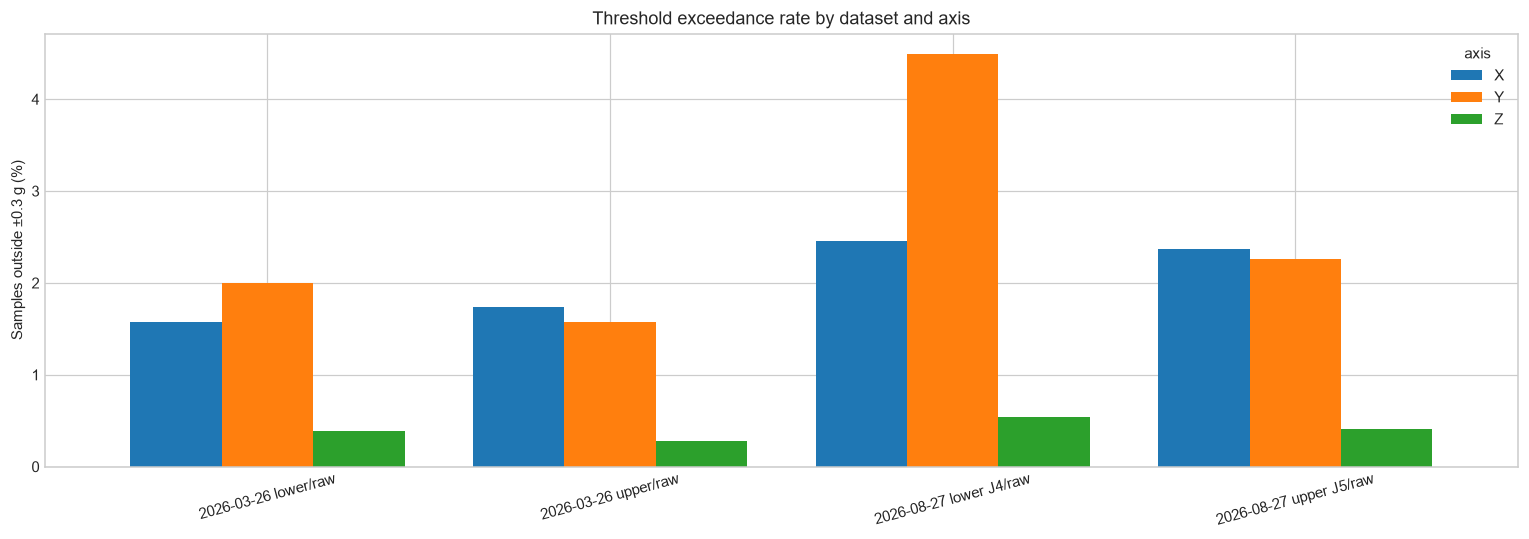

In [7]:
threshold_summary = metrics[["RMS_g", "min_g", "max_g", "outside_0.3g_count", "outside_0.3g_pct"]].copy()
display(threshold_summary.round(6))
ax = threshold_summary["outside_0.3g_pct"].unstack("axis").plot.bar(figsize=(14, 5), width=0.8)
ax.set_ylabel("Samples outside ±0.3 g (%)")
ax.set_xlabel("")
ax.set_title("Threshold exceedance rate by dataset and axis")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


## Vendor-oriented quantitative improvement

The vendor criterion is strictly **|acceleration| < 0.3 g while transporting 265 wafers**. These recordings were made with 250 wafers, so the tables below quantify improvement after the July mechanical changes but **do not constitute 265-wafer acceptance evidence**. Positive improvement means the August value is lower/better; a negative value means regression.


RMS_g


benchmark  2026-08-27  improvement_%
gripper       baseline             axis                                      
Upper gripper 2026-03-26 upper/raw X        0.0882      0.1001       -13.4468
                                   Y        0.0899      0.1060       -17.9634
                                   Z        0.0471      0.0546       -15.7678
Lower gripper 2026-03-26 lower/raw X        0.0935      0.1082       -15.7849
                                   Y        0.0922      0.1360       -47.4396
                                   Z        0.0486      0.0583       -19.9432


p99_abs_g


benchmark  2026-08-27  improvement_%
gripper       baseline             axis                                      
Upper gripper 2026-03-26 upper/raw X        0.3717      0.3950        -6.2758
                                   Y        0.3687      0.4043        -9.6729
                                   Z        0.2024      0.2227       -10.0391
Lower gripper 2026-03-26 lower/raw X        0.3620      0.4138       -14.3175
                                   Y        0.3980      0.5684       -42.8236
                                   Z        0.2000      0.2145        -7.2291


p99.9_abs_g


...

benchmark  2026-08-27  improvement_%
gripper       baseline             axis                                      
Upper gripper 2026-03-26 upper/raw X      119.2367    203.9830       -71.0740
                                   Y      117.0993    150.8962       -28.8618
                                   Z      113.1298    126.4866       -11.8065
Lower gripper 2026-03-26 lower/raw X       81.8321    139.7747       -70.8068
                                   Y      122.7481    322.4790      -162.7161
                                   Z       95.1145    130.8170       -37.5363


max_exceedance_duration_ms


benchmark  2026-08-27  improvement_%
gripper       baseline             axis                                      
Upper gripper 2026-03-26 upper/raw X      106.4453     73.2422        31.1927
                                   Y       88.8671    102.5390       -15.3846
                                   Z       16.6016      9.7656        41.1765
Lower gripper 2026-03-26 lower/raw X       93.7500    107.4218       -14.5833
                                   Y       39.0625     43.9453       -12.4999
                                   Z        9.7656     15.6250       -59.9999

August 250-wafer threshold evidence (not a 265-wafer acceptance test):


within_0.3g_pct  outside_0.3g_count  \
dataset                 axis                                        
2026-08-27 upper J5/raw X           97.625967                8545   
                        Y           97.736264                8148   
                        Z           99.595206                1457   
2026-08-27 lower J4/raw X           97.541538                8937   
                        Y           95.510288               16321   
                        Z           99.462753                1953   

                              outside_0.3g_seconds  max_abs_g  \
dataset                 axis                                    
2026-08-27 upper J5/raw X                 8.344722   0.811142   
                        Y                 7.957027   0.964001   
                        Z                 1.422851   1.127728   
2026-08-27 lower J4/raw X                 8.727535   0.995267   
                        Y                15.938468   1.598856   
                        Z                 1.907226   1.071680   

                              all_samples_strictly_below_0.3g  
dataset                 axis                                   
2026-08-27 upper J5/raw X                               False  
                        Y                               False  
                        Z                               False  
2026-08-27 lower J4/raw X                               False  
                        Y                               False  
                        Z                               False

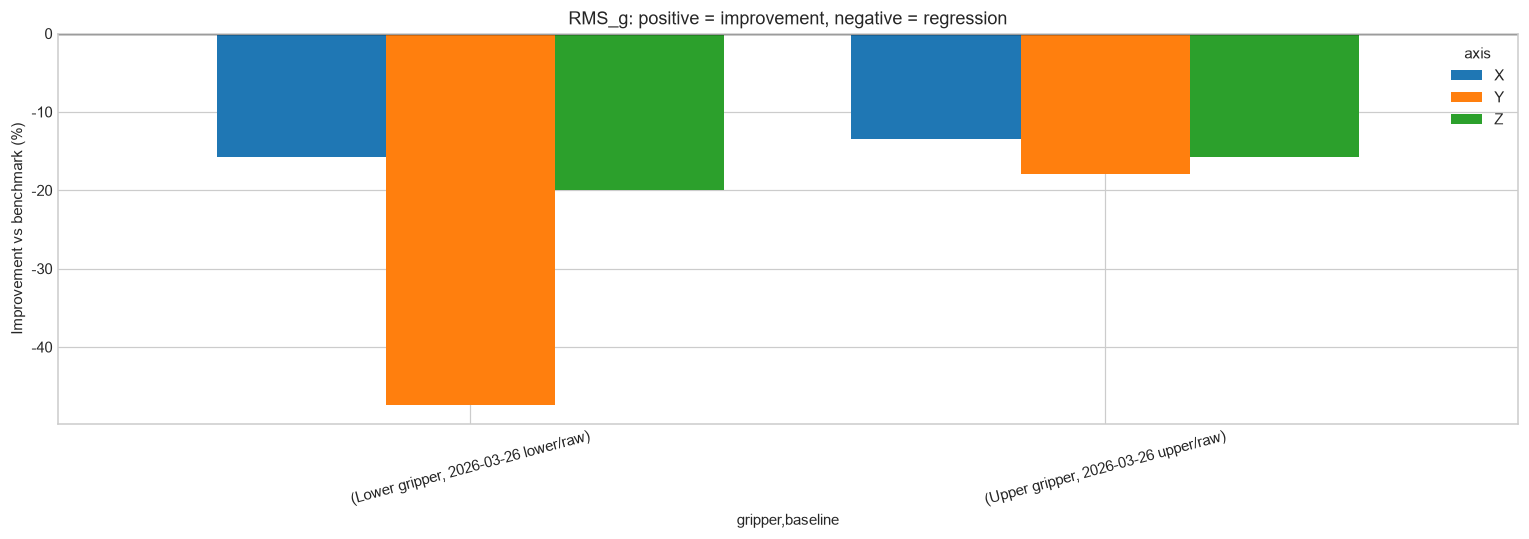

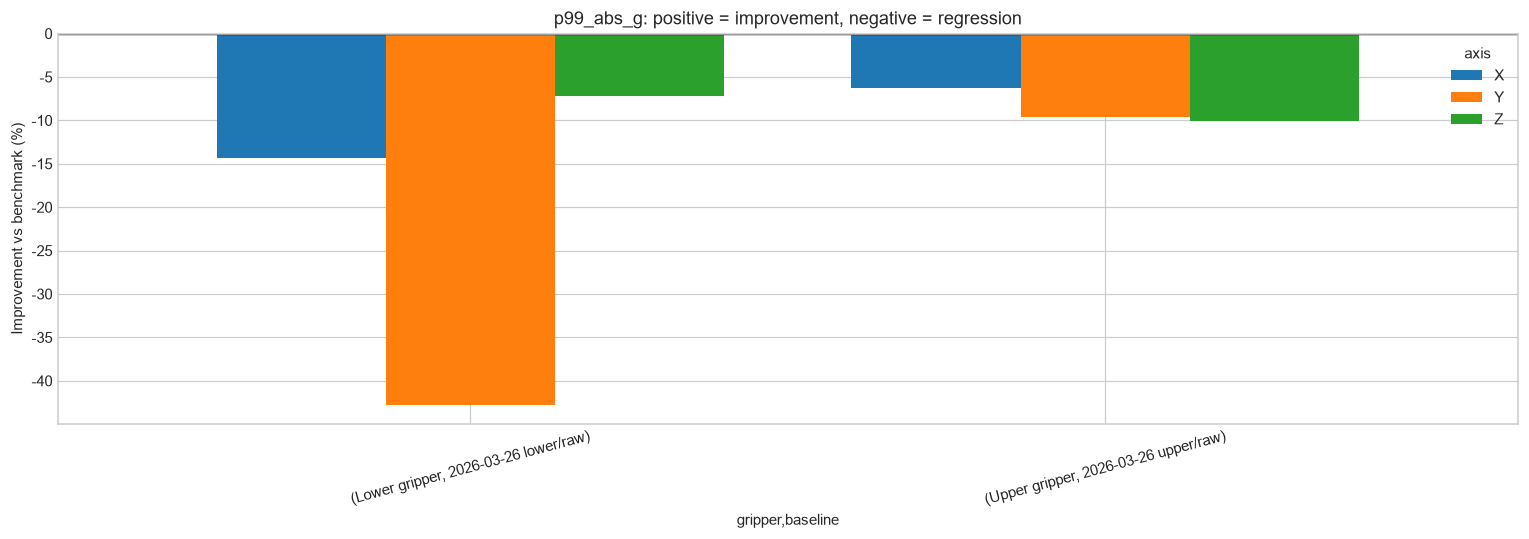

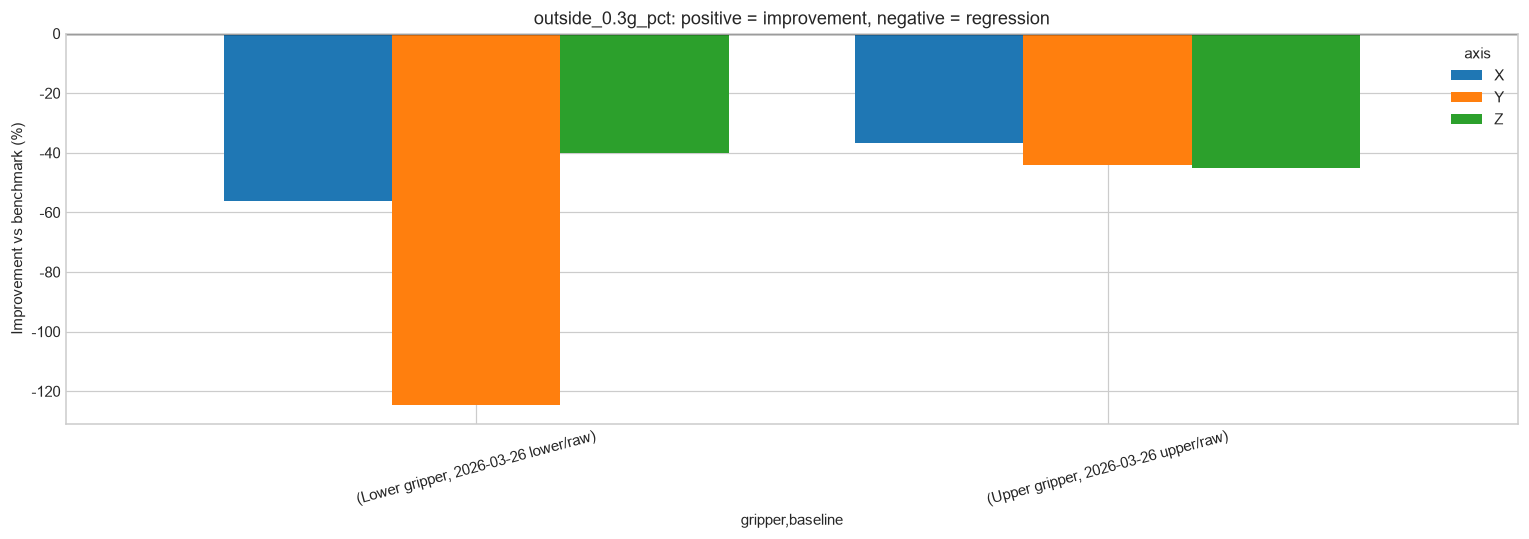

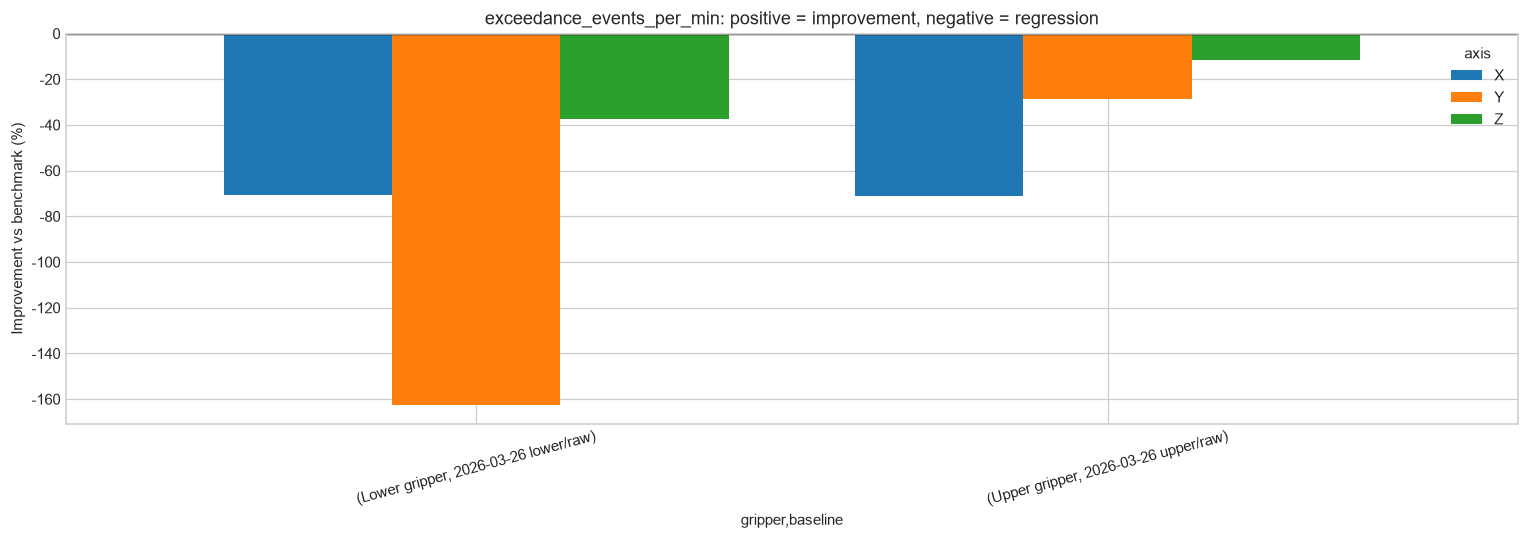

In [8]:
LOWER_IS_BETTER = [
    "RMS_g", "p99_abs_g", "p99.9_abs_g", "max_abs_g",
    "outside_0.3g_pct", "exceedance_events_per_min", "max_exceedance_duration_ms",
]
comparison_rows = []
for gripper, labels in GROUPS.items():
    current_label = next(label for label in labels if "2026-08-27" in label)
    baseline_labels = [label for label in labels if label != current_label]
    baseline_sets = [(label, metrics.loc[label]) for label in baseline_labels]
    if len(baseline_labels) > 1:
        baseline_sets.append(("Mean of baselines", pd.concat([metrics.loc[label] for label in baseline_labels]).groupby(level=0).mean()))
    current = metrics.loc[current_label]
    for baseline_name, baseline in baseline_sets:
        for axis in ["X", "Y", "Z"]:
            row = {"gripper": gripper, "baseline": baseline_name, "axis": axis}
            for metric in LOWER_IS_BETTER:
                old, new = baseline.loc[axis, metric], current.loc[axis, metric]
                row[f"{metric}__baseline"] = old
                row[f"{metric}__august"] = new
                row[f"{metric}__improvement_pct"] = 100 * (old - new) / old if old != 0 else np.nan
            comparison_rows.append(row)
improvement = pd.DataFrame(comparison_rows).set_index(["gripper", "baseline", "axis"])

for metric in LOWER_IS_BETTER:
    print(f"\n{metric}")
    display(improvement[[f"{metric}__baseline", f"{metric}__august", f"{metric}__improvement_pct"]]
            .rename(columns={f"{metric}__baseline": "benchmark", f"{metric}__august": "2026-08-27", f"{metric}__improvement_pct": "improvement_%"})
            .round(4))

current_labels = [label for label in metrics.index.get_level_values(0).unique() if "2026-08-27" in label]
acceptance = metrics.loc[current_labels, ["within_0.3g_pct", "outside_0.3g_count", "outside_0.3g_seconds", "max_abs_g"]].copy()
acceptance["all_samples_strictly_below_0.3g"] = acceptance["outside_0.3g_count"].eq(0)
print("August 250-wafer threshold evidence (not a 265-wafer acceptance test):")
display(acceptance.round(6))

for metric in ["RMS_g", "p99_abs_g", "outside_0.3g_pct", "exceedance_events_per_min"]:
    chart = improvement[f"{metric}__improvement_pct"].unstack("axis")
    ax = chart.plot.bar(figsize=(14, 5), width=0.8)
    ax.axhline(0, color="black", linewidth=0.9)
    ax.set_ylabel("Improvement vs benchmark (%)")
    ax.set_title(f"{metric}: positive = improvement, negative = regression")
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()
